In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA


Wczytanie zbioru twarzy Olivetti

In [2]:
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data # shape (400, 64*64)
dim = faces.images.shape[1] # 64

Dekompozycja PCA zbioru

In [3]:
n_components = 30

In [4]:
pca   = PCA(n_components=n_components, svd_solver="randomized", whiten=True, 
            random_state=42)
X_pca = pca.fit_transform(X)
X_rec = pca.inverse_transform(X_pca)

Podląd rekonstrukcji przykładowych twarzy dla wybranej liczby składowych

In [5]:
show = np.array([376, 185,  13, 379, 328,  57, 298, 201])

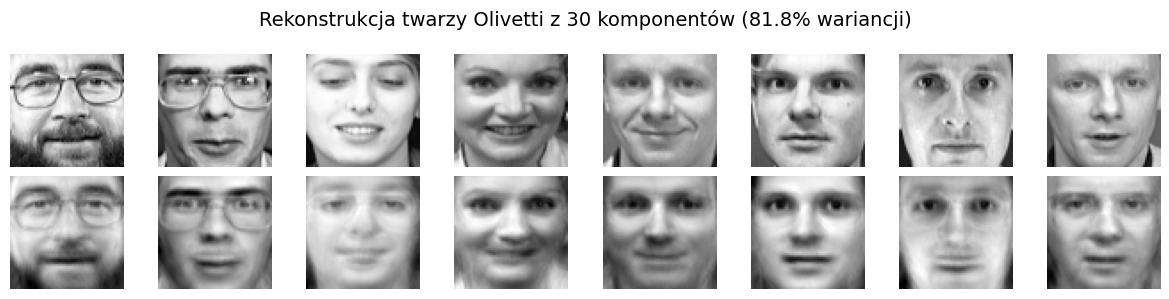

In [6]:
fig, axes = plt.subplots(2, len(show), figsize=(1.5 * len(show), 3))
for i, s in enumerate(show):
    axes[0, i].imshow(X[s].reshape(dim, dim),  cmap='gray')
    axes[1, i].imshow(X_rec[s].reshape(dim, dim), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].axis('off')
ev_ratio = pca.explained_variance_ratio_.sum()
fig.suptitle(f'Rekonstrukcja twarzy Olivetti z {n_components} komponentów ({ev_ratio:.1%} wariancji)', fontsize=14)
plt.tight_layout()
plt.show()